# Notebook 04: Segmentation and Heterogeneous Treatment Effects

### Purpose
- Determines whether the email campaign's impact was uniform or whether certain customer segments drove the effect — with direct implications for targeting strategy.

### Objectives
- Treatment effects across segments defined by recency, channel, prior spend, and customer tenure.
- Whether observed differences across segments reflect genuine heterogeneity or chance variation.
- Which findings are strong enough to act on and which require a follow-up experiment to confirm.

In [2]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
from statsmodels.stats import multitest
import matplotlib.pyplot as plt

In [3]:
hillstrom_df = pd.read_csv("../data/raw/hillstrom.csv")

hillstrom_df

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0


In [4]:
mens_control_df = hillstrom_df[hillstrom_df["segment"].isin(["No E-Mail", "Mens E-Mail"])].copy()

mens_control_df["recency_group"] = np.where(mens_control_df["recency"] < mens_control_df["recency"].median(), "recent", "non-recent")

mens_control_df["history_group"] = mens_control_df["history_segment"].map({
    '1) $0 - $100': 'low',
    '2) $100 - $200': 'mid',
    '3) $200 - $350': 'mid',
    '4) $350 - $500': 'high',
    '5) $500 - $750': 'high',
    '6) $750 - $1,000': 'high',
    '7) $1,000 +': 'high'
})

mens_control_df

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,recency_group,history_group
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,non-recent,mid
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,non-recent,high
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0,non-recent,high
13,2,2) $100 - $200,101.64,0,1,Urban,0,Web,Mens E-Mail,1,0,0.0,recent,mid
14,4,3) $200 - $350,241.42,0,1,Rural,1,Multichannel,No E-Mail,0,0,0.0,recent,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63994,7,1) $0 - $100,86.46,0,1,Urban,0,Web,Mens E-Mail,0,0,0.0,non-recent,low
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0,non-recent,mid
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0,recent,low
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0,non-recent,low



Visit Rate


,cov,level,n_treated,n_control,n_total
0,channel,Multichannel,2577,2606,5183
1,channel,Phone,9240,9327,18567
2,channel,Web,9490,9373,18863
3,recency_group,non-recent,10685,10630,21315
4,recency_group,recent,10622,10676,21298
5,history_group,high,4802,4814,9616
6,history_group,low,7724,7612,15336
7,history_group,mid,8781,8880,17661
8,mens,0,9568,9519,19087
9,mens,1,11739,11787,23526


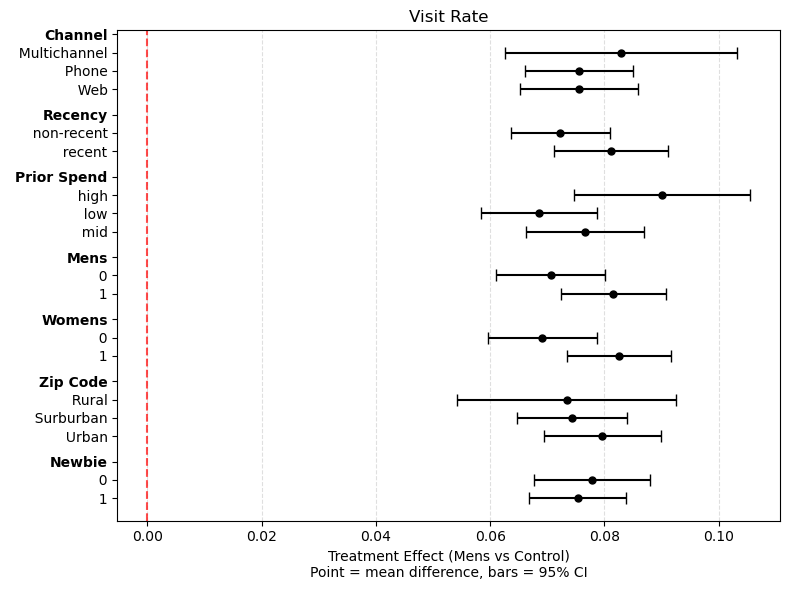


Conversion Rate


,cov,level,n_treated,n_control,n_total
0,channel,Multichannel,2577,2606,5183
1,channel,Phone,9240,9327,18567
2,channel,Web,9490,9373,18863
3,recency_group,non-recent,10685,10630,21315
4,recency_group,recent,10622,10676,21298
5,history_group,high,4802,4814,9616
6,history_group,low,7724,7612,15336
7,history_group,mid,8781,8880,17661
8,mens,0,9568,9519,19087
9,mens,1,11739,11787,23526


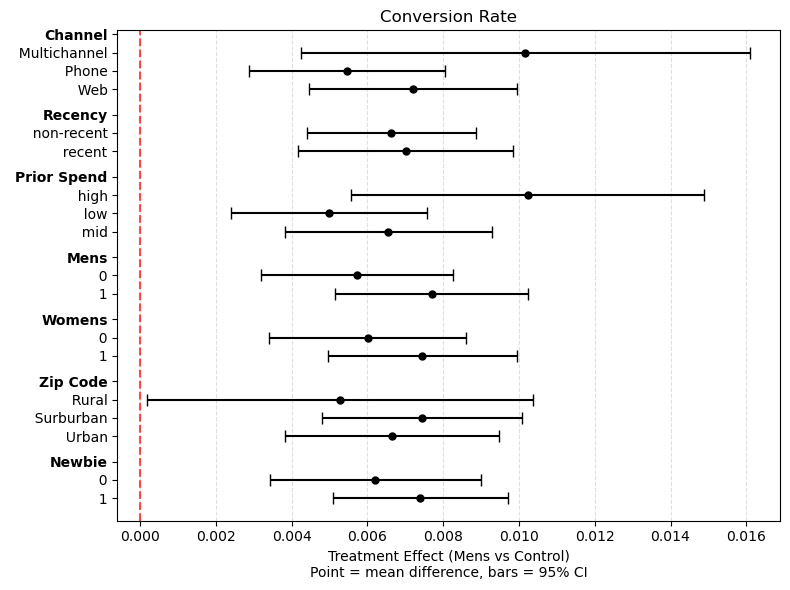


Spend ($)


,cov,level,n_treated,n_control,n_total
0,channel,Multichannel,2577,2606,5183
1,channel,Phone,9240,9327,18567
2,channel,Web,9490,9373,18863
3,recency_group,non-recent,10685,10630,21315
4,recency_group,recent,10622,10676,21298
5,history_group,high,4802,4814,9616
6,history_group,low,7724,7612,15336
7,history_group,mid,8781,8880,17661
8,mens,0,9568,9519,19087
9,mens,1,11739,11787,23526


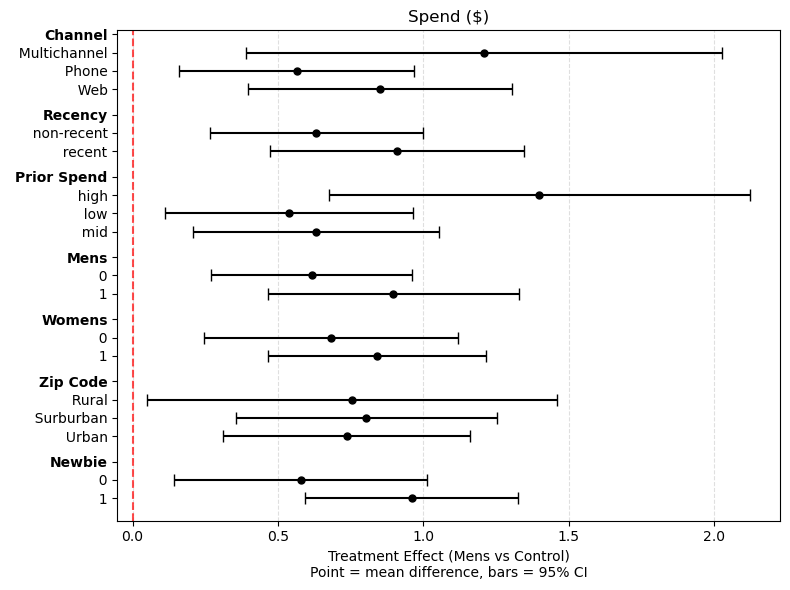

In [8]:
def compute_effects(outcome, cov_labels, df):
    results = []
    for cov in cov_labels:
        stats = df.groupby([cov, "segment"])[[outcome]].agg(["mean", "sem", "count"])
        for level in sorted(df[cov].unique()):
            n_treated = int(stats.loc[(level, "Mens E-Mail"), (outcome, "count")])
            n_control = int(stats.loc[(level, "No E-Mail"), (outcome, "count")])
            diff = stats.loc[(level, "Mens E-Mail"), (outcome, "mean")] - stats.loc[(level, "No E-Mail"), (outcome, "mean")]
            se = np.sqrt(stats.loc[(level, "Mens E-Mail"), (outcome, "sem")]**2 + stats.loc[(level, "No E-Mail"), (outcome, "sem")]**2)
            results.append({
                "cov": cov, "level": level,
                "n_treated": n_treated, "n_control": n_control,
                "effect": diff, "ci_low": diff - 1.96 * se, "ci_high": diff + 1.96 * se,
            })
    return results


def forest_plot(results, cov_labels, outcome_label, ax):
    """
    Draw a forest plot on ax.

    results: list of dicts with keys: cov, level, effect, ci_low, ci_high
    cov_labels: dict mapping cov name -> display label (used as group headers)
    """
    y_positions, y_labels, header_ys, plot_items = [], [], set(), []
    current_y = 0
    prev_cov = None

    for r in results:
        if r["cov"] != prev_cov:
            if prev_cov is not None:
                current_y -= 0.4
            y_positions.append(current_y)
            y_labels.append(cov_labels[r["cov"]])
            header_ys.add(current_y)
            current_y -= 1
            prev_cov = r["cov"]

        y_positions.append(current_y)
        y_labels.append(f"  {r['level']}")
        plot_items.append((current_y, r))
        current_y -= 1

    for y, r in plot_items:
        ax.errorbar(
            r["effect"], y,
            xerr=[[r["effect"] - r["ci_low"]], [r["ci_high"] - r["effect"]]],
            fmt="o", color="black", capsize=4, markersize=5,
        )

    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Treatment Effect (Mens vs Control)\nPoint = mean difference, bars = 95% CI")
    ax.set_title(outcome_label)

    for tick, y in zip(ax.get_yticklabels(), y_positions):
        if y in header_ys:
            tick.set_fontweight("bold")


cov_labels = {"channel": "Channel", "recency_group": "Recency", "history_group": "Prior Spend",
              "mens": "Mens", "womens": "Womens", "zip_code": "Zip Code", "newbie": "Newbie"}

outcome_labels = {"visit": "Visit Rate", "conversion": "Conversion Rate", "spend": "Spend ($)"}

for outcome, label in outcome_labels.items():

    print(f"\n{'='*40}")
    print(f"{label}")
    print(f"{'='*40}")

    results = compute_effects(outcome, cov_labels, mens_control_df)

    counts_df = pd.DataFrame(results)[["cov", "level", "n_treated", "n_control"]]
    counts_df["n_total"] = counts_df["n_treated"] + counts_df["n_control"]
    display(counts_df)

    fig, ax = plt.subplots(figsize=(8, 6))
    forest_plot(results, cov_labels, outcome_label=label, ax=ax)
    plt.tight_layout()
    if outcome == "spend":
        plt.savefig("../reports/figures/forest_plot_spend.png", dpi=150, bbox_inches="tight")
    plt.show()

### Check statistical significance

In [147]:
mens_control_df["treatment"] = (mens_control_df["segment"] == "Mens E-Mail").astype(int)

results = []

for metric in ["visit", "conversion", "spend"]:

    for cov in cov_labels:

        model = smf.ols(f"{metric} ~ treatment * C({cov})", data=mens_control_df).fit(cov_type='HC3')
        for k in model.pvalues.index:
            if "treatment:C" in k:
                results.append({"metric": metric, "covariate": cov, "term": k, "pval": model.pvalues[k]})

results_df = pd.DataFrame(results)

results_df["Adjusted P-Value"] = multitest.multipletests(results_df["pval"].astype(float), method="fdr_bh")[1]

results_df

,metric,covariate,term,pval,Adjusted P-Value
0,visit,channel,treatment:C(channel)[T.Phone],0.521862,0.717802
1,visit,channel,treatment:C(channel)[T.Web],0.526388,0.717802
2,visit,recency_group,treatment:C(recency_group)[T.recent],0.189651,0.474128
3,visit,history_group,treatment:C(history_group)[T.low],0.021966,0.406347
4,visit,history_group,treatment:C(history_group)[T.mid],0.153038,0.474128
5,visit,mens,treatment:C(mens)[T.1],0.103911,0.474128
6,visit,womens,treatment:C(womens)[T.1],0.047687,0.406347
7,visit,zip_code,treatment:C(zip_code)[T.Surburban],0.931674,0.963800
8,visit,zip_code,treatment:C(zip_code)[T.Urban],0.573159,0.736293
9,visit,newbie,treatment:C(newbie)[T.1],0.708214,0.817170


## Summary

- The men's email campaign lifted visit rates, conversion, and spend consistently across all customer segments. Point estimates varied somewhat across recency, channel, prior spend, and customer tenure, but confidence intervals overlapped heavily in every case.
- Interaction tests found no statistically significant heterogeneity after correcting for multiple comparisons (Benjamini-Hochberg). The low prior spend group showed a nominally significant interaction (p=0.02) that did not survive correction - a likely false positive given the number of tests run.
- The appropriate conclusion is that the campaign worked broadly, not for a specific segment. Any follow-up targeting decision based on the subgroup patterns observed here would require a dedicated experiment powered for that segment.
